### Imports & Load data

In [18]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/train.csv")

### Shape, info, describe and Null value check

In [10]:
print(f"shape is : {df.shape}")
print(f"Info of dataset:\n{df.info()}")
print(f"Dataset Description:\n{df.describe()}")
print(f"Num of Null values:\n{df.isnull().sum()}")

shape is : (2000, 21)
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 1

### Class distribution check

In [ ]:
#check class distribution 
print(df['price_range'].value_counts())

#check zero counts for suspicious columns
suspicious= ['px_height','px_width','sc_h','sc_w','ram','talk_time','battery_power']

for feature in suspicious:
    zero_count = (df[feature]== 0 ).sum()
    print(f"{feature}:{zero_count} zeros")



price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64
px_height:2 zeros
px_width:0 zeros
sc_h:0 zeros
sc_w:180 zeros
ram:0 zeros
talk_time:0 zeros
battery_power:0 zeros
2


px_height has 2 zero values - physically impossible, will be dropped in preprocessing

sc_w has 180 zero values - will be replaced with mean in preprocessing


Dataset is perfectly balanced with 500 samples per class

NO class imbalance treatment needed

In [11]:
df.head

<bound method NDFrame.head of       battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  \
0               842     0          2.2         0   1       0           7   
1              1021     1          0.5         1   0       1          53   
2               563     1          0.5         1   2       1          41   
3               615     1          2.5         0   0       0          10   
4              1821     1          1.2         0  13       1          44   
...             ...   ...          ...       ...  ..     ...         ...   
1995            794     1          0.5         1   0       1           2   
1996           1965     1          2.6         1   0       0          39   
1997           1911     0          0.9         1   1       1          36   
1998           1512     0          0.9         0   4       1          46   
1999            510     1          2.0         1   5       1          45   

      m_dep  mobile_wt  n_cores  ...  px_height  px_width

{'whiskers': [<matplotlib.lines.Line2D at 0x1cc12c4e990>,
 'caps': [<matplotlib.lines.Line2D at 0x1cc12c4d790>,
 'boxes': [<matplotlib.lines.Line2D at 0x1cc12c4e780>],
 'medians': [<matplotlib.lines.Line2D at 0x1cc12af2360>],
 'fliers': [<matplotlib.lines.Line2D at 0x1cc12af0a70>],
 'means': []}

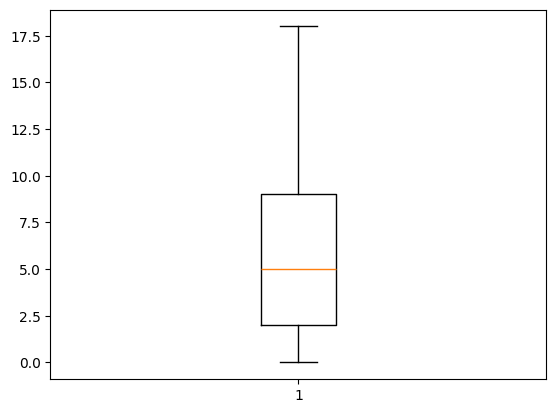

In [17]:
plt.boxplot(df['sc_w'])

### Feature distributions (histograms)

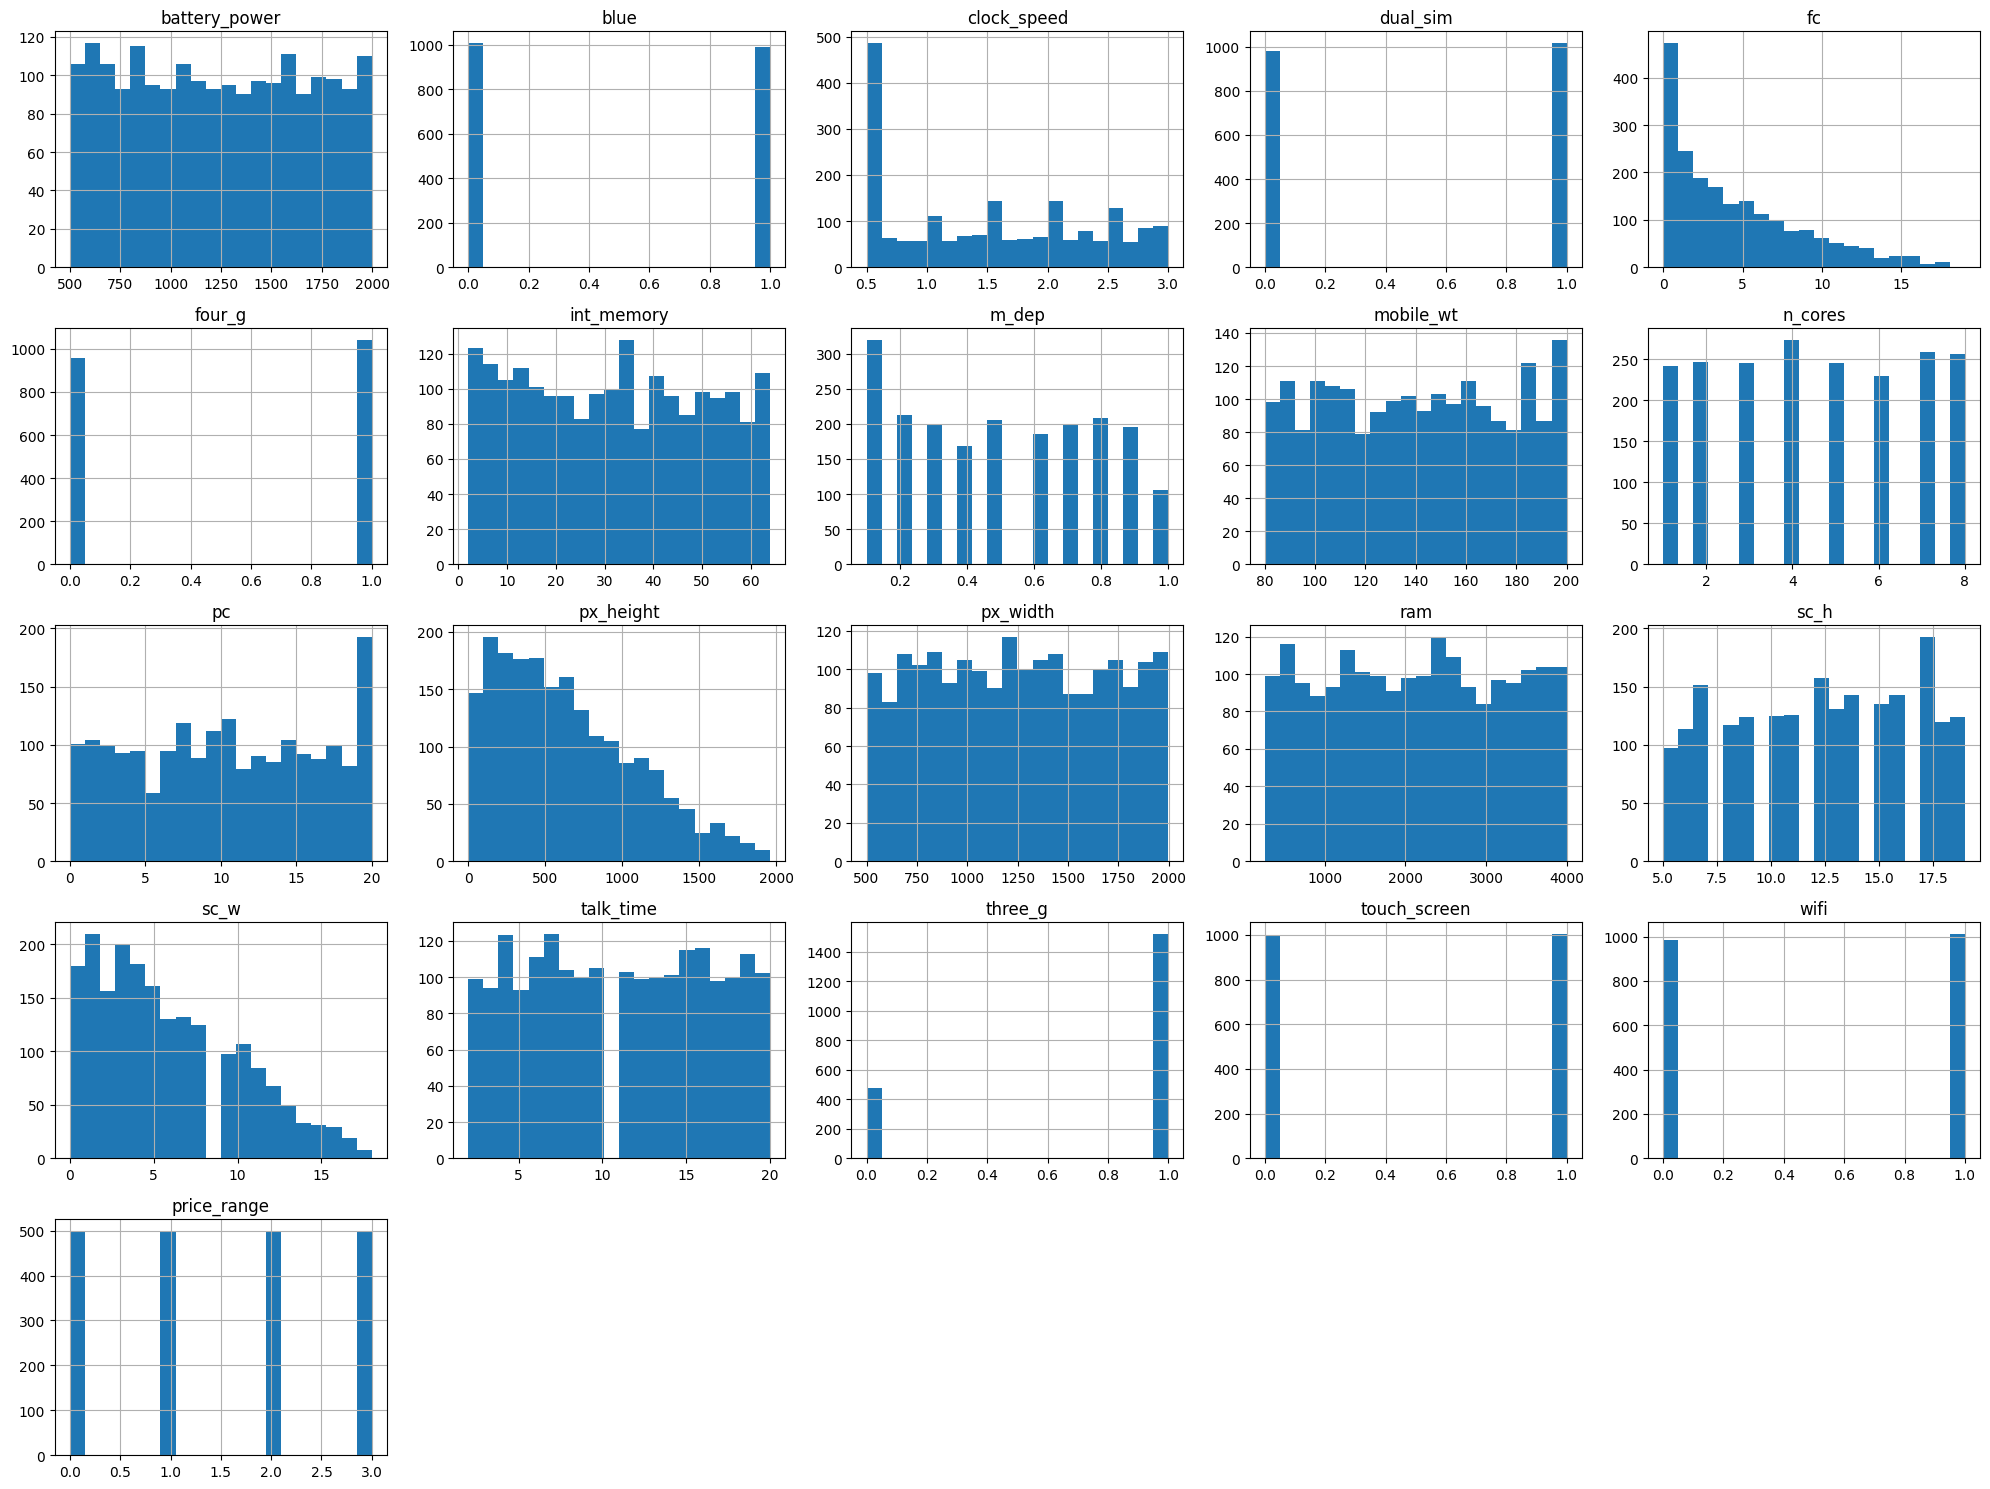

In [19]:
df.hist(figsize=(20,15),bins=20)# 20 bars 
plt.tight_layout() # prevents the subplott overlapping together
plt.show()

### Correlation Heatmap

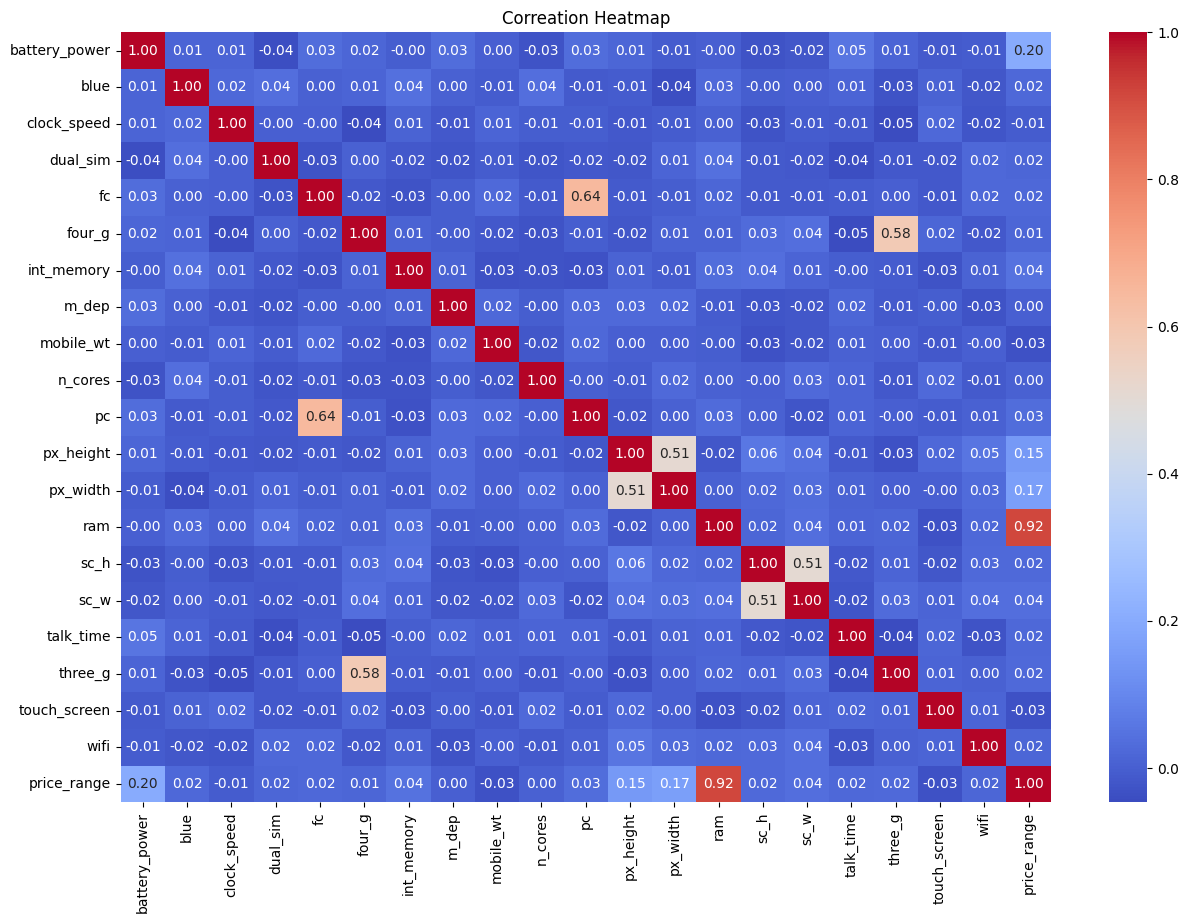

In [20]:

plt.figure(figsize=(15,10))
sns.heatmap(df.corr(),annot=True,fmt = '.2f',cmap='coolwarm')
plt.title("Correation Heatmap")
plt.show()

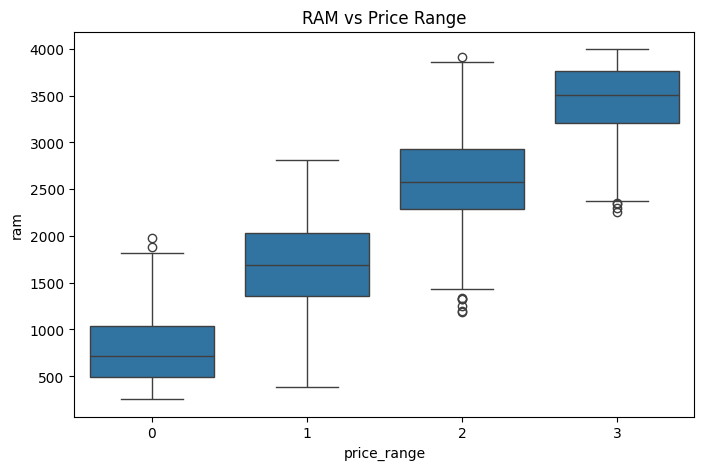

In [21]:
plt.figure(figsize = (8,5))
sns.boxplot(x= 'price_range',y = 'ram',data=df)
plt.title("RAM vs Price Range")
plt.show()